In [1]:
import sys
sys.path.append("/home/mike/git/QDMpy/src")

In [2]:
from QDMpy import models

12:32:46.596     INFO QDMpy.<module> >> WELCOME TO QDMpy
12:32:46.597    DEBUG QDMpy.<module> >> QDMpy version 0.1.0a installed at /home/mike/git/QDMpy/src/QDMpy
12:32:46.597    DEBUG QDMpy.<module> >> QDMpy config file /home/mike/.config/QDMpy/config.ini
12:32:46.598     INFO QDMpy.load_config >> Loading config file: /home/mike/.config/QDMpy/config.ini
0 <class 'ctypes.c_ulong'>
1 <class 'ctypes.c_ulong'>
2 <class 'pygpufit.gpufit.LP_c_float'>
3 <class 'pygpufit.gpufit.LP_c_float'>
4 <class 'ctypes.c_int'>
5 <class 'pygpufit.gpufit.LP_c_float'>
6 <class 'pygpufit.gpufit.LP_c_float'>
7 <class 'pygpufit.gpufit.LP_c_int'>
8 <class 'ctypes.c_float'>
9 <class 'ctypes.c_int'>
10 <class 'pygpufit.gpufit.LP_c_int'>
11 <class 'ctypes.c_int'>
12 <class 'ctypes.c_ulong'>
13 <class 'ctypes.LP_c_char'>
14 <class 'pygpufit.gpufit.LP_c_float'>
15 <class 'pygpufit.gpufit.LP_c_int'>
16 <class 'pygpufit.gpufit.LP_c_float'>
17 <class 'pygpufit.gpufit.LP_c_int'>
12:32:46.599     INFO QDMpy.<module> >> CU

This tutorial will guide you through the models.py file, which defines models for fitting Optically Detected Magnetic Resonance (ODMR) spectra. These models are used to analyze data from Nitrogen-Vacancy (NV) centers in diamond. The file includes models for different nitrogen isotopes (`14N` and `15N`) and a single resonance model, along with a registry system for managing these models.

---

## 1. **Overview of the File**

The file contains:
- **Model Functions**: Functions to calculate the response of different ODMR models (`esr14n`, `esr15n`, `esrsingle`).
- **Abstract Base Class (`Model`)**: A base class defining the interface for all ODMR models.
- **Concrete Model Classes**: Specific implementations for `14N`, `15N`, and single resonance models.
- **Model Registry**: A system to register, retrieve, and manage models.

---

## 2. **Model Functions**

### `esr14n`
This function calculates the response for NV centers with the `14N` isotope. It models three resonance dips caused by hyperfine splitting.

```python
def esr14n(x: NDArray, parameter: NDArray, ahyp: float = AHYP_14N) -> NDArray:
    ...
```

- **Inputs**:
  - `x`: Independent variable (e.g., frequencies).
  - `parameter`: Array of parameters (center frequency, width, contrasts, offset).
  - `ahyp`: Hyperfine splitting constant (default: `AHYP_14N`).
- **Output**: Model response as an array.

### `esr15n`
This function calculates the response for NV centers with the `15N` isotope. It models two resonance dips.

```python
def esr15n(x: NDArray, parameter: NDArray, ahyp: float = AHYP_15N) -> NDArray:
    ...
```

- Similar to `esr14n`, but with two dips instead of three.

### `esrsingle`
This function calculates the response for a single resonance dip.

```python
def esrsingle(x: NDArray, parameter: NDArray) -> NDArray:
    ...
```

- **Inputs**:
  - `x`: Independent variable.
  - `parameter`: Array of parameters (center frequency, width, contrast, offset).
- **Output**: Model response as an array.

---

## 3. **Abstract Base Class: `Model`

The `Model` class defines the interface for all ODMR models. It includes:
- **Attributes**:
  - `name`: Unique identifier for the model.
  - `parameters_unique`: List of parameter names with unique identifiers.
  - `n_peaks`: Number of resonance peaks in the model.
- **Methods**:
  - `func`: Abstract method to evaluate the model.
  - `parameter`: Property to get base parameter names.
  - `n_parameters`: Property to get the number of parameters.
  - `get_constraint_array`: Method to create an array of constraints for parameters.

Example:
```python
class Model(ABC):
    def __init__(self, name: str, n_peaks: int, parameters_unique: list[str]) -> None:
        self.name = name
        self.parameters_unique = parameters_unique
        self.n_peaks = n_peaks

    @abstractmethod
    def func(self, x: NDArray, parameters: NDArray) -> NDArray:
        raise NotImplementedError
```

---

## 4. **Concrete Model Classes**

### `ESR14N`
Represents the `14N` model with three resonance dips.

```python
class ESR14N(Model):
    def __init__(self) -> None:
        super().__init__('ESR14N', 3, ['contrast', 'center', 'width_0', 'width_1', 'width_2', 'offset'])
        self.ahyp = AHYP_14N

    def func(self, x: NDArray, parameters: NDArray) -> NDArray:
        return esr14n(x, parameters, self.ahyp)
```

### `ESR15N`
Represents the `15N` model with two resonance dips.

```python
class ESR15N(Model):
    def __init__(self) -> None:
        super().__init__('ESR15N', 2, ['contrast', 'center', 'width_0', 'width_1', 'offset'])
        self.ahyp = AHYP_15N

    def func(self, x: NDArray, parameters: NDArray) -> NDArray:
        return esr15n(x, parameters, self.ahyp)
```

### `ESRSINGLE`
Represents the single resonance model.

```python
class ESRSINGLE(Model):
    def __init__(self) -> None:
        super().__init__('ESRSINGLE', 1, ['contrast', 'center', 'width_0', 'offset'])

    def func(self, x: NDArray, parameters: NDArray) -> NDArray:
        return esrsingle(x, parameters)
```

---

## 5. **Model Registry**

The `ModelRegistry` class manages all available models. It allows you to register, retrieve, and list models.

### Registering Models
Models are registered using the `register` method.

```python
ModelRegistry.register('ESR14N', {'class': ESR14N, 'hyp': AHYP_14N})
ModelRegistry.register('ESR15N', {'class': ESR15N, 'hyp': AHYP_15N})
ModelRegistry.register('ESRSINGLE', {'class': ESRSINGLE, 'hyp': 0.0})
```

### Retrieving Models
You can retrieve a model by its name using the `get` method.

```python
model = ModelRegistry.get('ESRSINGLE')
```

### Listing All Models
Use the `all` method to list all registered models.

```python
all_models = ModelRegistry.all()
```

---

## 6. **Example Usage**

Here’s an example of how to use the models:

### ESRSINGLE

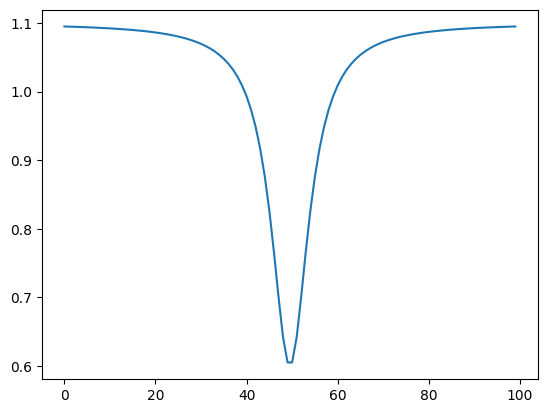

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from QDMpy.models import ModelRegistry

# Retrieve the ESRSINGLE model
model = ModelRegistry.get('ESRSINGLE')

# Define input data and parameters
x = np.linspace(2.8, 3.0, 100)  # Frequency range
parameters = np.array([[2.9, 0.01, 0.5, 0.1]])  # Example parameters

# Calculate the model response
response = model.func(x, parameters)

# Print the response
plt.plot(response.T)

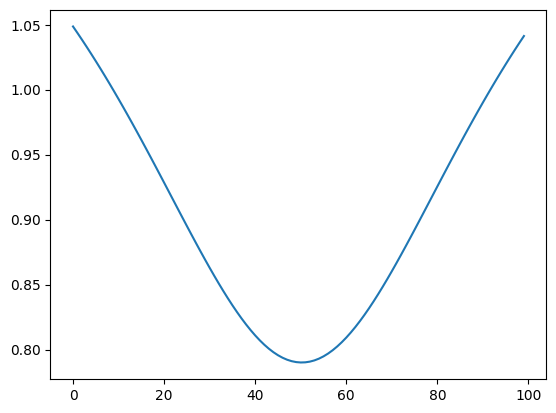

In [17]:
import numpy as np
import matplotlib.pyplot as plt
from QDMpy.models import ModelRegistry

# Retrieve the ESRSINGLE model
model = ModelRegistry.get('ESR15N')

# Define input data and parameters
x = np.linspace(2.8, 3.0, 100)  # Frequency range
parameters = np.array([[2.9, 0.1, 0.01, 0.5, 0.3]])  # Example parameters

# Calculate the model response
response = model.func(x, parameters)

# Print the response
plt.plot(response.T)

## 7. **Extending the Models**

To add a new model:
1. Create a new function for the model response.
2. Define a new class inheriting from `Model`.
3. Implement the `func` method.
4. Register the model using `ModelRegistry.register`.